Context: This dataset was created to analyze customer behavior and understand the factors that lead to customer churn. It focuses on identifying patterns related to customer demographics, account details, and financial activity in order to support data-driven decision-making and improve customer retention strategies.

Source: The data is based on a publicly available customer churn dataset commonly used for educational and research purposes in data science and machine learning projects. It has been adapted and cleaned for analytical use.

Inspiration: The inspiration behind this dataset comes from the growing need for businesses, especially in the banking and financial sector, to predict customer churn and take proactive actions to retain valuable customers. By studying this data, analysts can gain insights into customer behavior and develop predictive models to reduce customer loss

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [2]:
df = pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Pandas Profiling Report")
profile.to_file("customer_churn_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 45.76it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<Axes: xlabel='Geography', ylabel='count'>

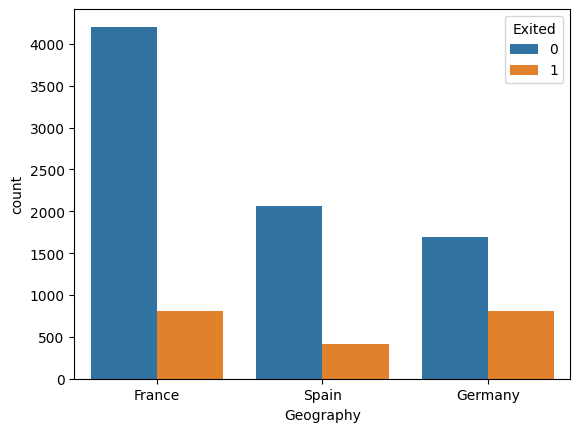

In [23]:
sns.countplot(x=df['Geography'], hue=df['Exited'])


In [7]:
%matplotlib inline

<Axes: xlabel='Age', ylabel='Count'>

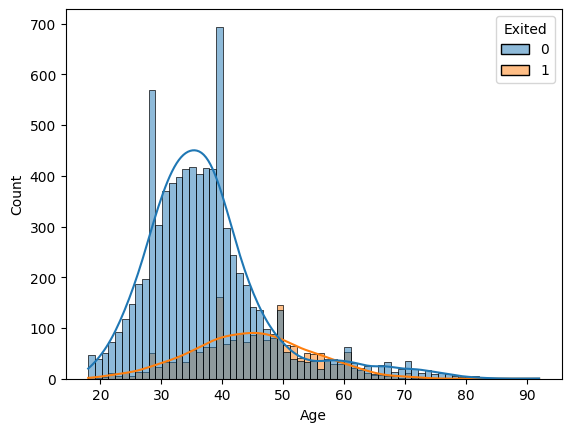

In [24]:
sns.histplot(x=df['Age'], hue=df['Exited'], kde=True)

In [9]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
new_df=df[['CreditScore','Gender','IsActiveMember', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']]

In [11]:
new_df.head()

,CreditScore,Gender,IsActiveMember,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited
0,619,Female,1,42,2,0.00,1,101348.88,1
1,608,Female,1,41,1,83807.86,1,112542.58,0
2,502,Female,0,42,8,159660.80,3,113931.57,1
3,699,Female,0,39,1,0.00,2,93826.63,0
4,850,Female,1,43,2,125510.82,1,79084.10,0


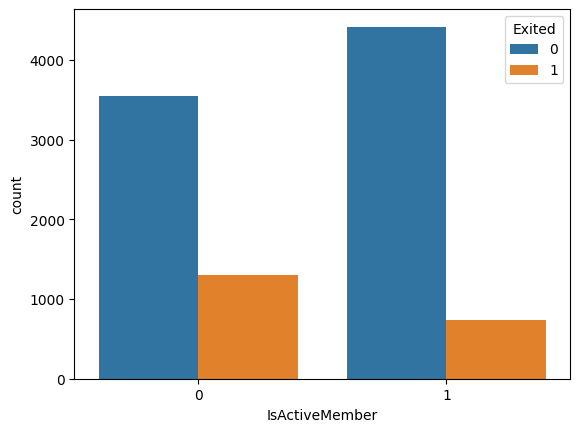

In [22]:
#checking inactive members likely to churn
sns.countplot(x=new_df['IsActiveMember'], hue=new_df['Exited'])
plt.show()

In [13]:
#split the data before transforming
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    new_df.drop('Exited',axis=1),
    new_df['Exited'],
    test_size=0.2,shuffle=False
)

In [14]:
x_train.head()

,CreditScore,Gender,IsActiveMember,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
0,619,Female,1,42,2,0.00,1,101348.88
1,608,Female,1,41,1,83807.86,1,112542.58
2,502,Female,0,42,8,159660.80,3,113931.57
3,699,Female,0,39,1,0.00,2,93826.63
4,850,Female,1,43,2,125510.82,1,79084.10


In [15]:
x_train.head()

,CreditScore,Gender,IsActiveMember,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
0,619,Female,1,42,2,0.00,1,101348.88
1,608,Female,1,41,1,83807.86,1,112542.58
2,502,Female,0,42,8,159660.80,3,113931.57
3,699,Female,0,39,1,0.00,2,93826.63
4,850,Female,1,43,2,125510.82,1,79084.10


In [16]:
#import the columntransformer for feature engineering....
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer(transformers=[
    ('tnfr1',StandardScaler(),['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']),
    ('tnfr2',OneHotEncoder(drop='first',sparse_output=False),['Gender'])
],remainder='passthrough')



'''now we use the methods for the feature enginerring
1.Creditscore,age,tenure,balance,estimated salary,number of product--->> standardscaler
2.gender--->> one hot encoding
'''


'now we use the methods for the feature enginerring\n1.Creditscore,age,tenure,balance,estimated salary,number of product--->> standardscaler\n2.gender--->> one hot encoding\n'

In [17]:
x_train_transformed=transformer.fit_transform(x_train)

In [18]:
#getting the featues out for making the dataframe after the transormation as we get the numpy array..
features=transformer.get_feature_names_out()
features

array(['tnfr1__CreditScore', 'tnfr1__Age', 'tnfr1__Tenure',
       'tnfr1__Balance', 'tnfr1__NumOfProducts', 'tnfr1__EstimatedSalary',
       'tnfr2__Gender_Male', 'remainder__IsActiveMember'], dtype=object)

In [19]:
x_train_transformed=pd.DataFrame(x_train_transformed,columns=features)

In [20]:
x_test_transformed=pd.DataFrame(transformer.transform(x_test),columns=features)

In [21]:
x_test_transformed.head()

,tnfr1__CreditScore,tnfr1__Age,tnfr1__Tenure,tnfr1__Balance,tnfr1__NumOfProducts,tnfr1__EstimatedSalary,tnfr2__Gender_Male,remainder__IsActiveMember
0,0.999815,-0.279516,1.035731,0.413598,0.809514,1.399417,1.0,1.0
1,0.586755,-0.660086,1.382448,-1.231021,0.809514,0.456833,1.0,0.0
2,-0.621445,-0.184374,-1.391289,-1.231021,0.809514,0.579575,1.0,0.0
3,-0.487200,1.718473,0.342296,0.452028,0.809514,-0.222292,1.0,1.0
4,-0.363282,0.576765,-0.004421,-1.231021,0.809514,1.124610,1.0,1.0


In [36]:
#using the randomForestclasifeir to deal with the basi variance tradeoff 
#imorting the randomForest....
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight='balanced',
                               bootstrap=True,
                              criterion= 'gini',
                              min_samples_split=5,
                              n_estimators=250,
                              random_state=42,
                              max_features='log2',
                              max_depth=12) #to understand the hyperparameter visit the RandomForestClassifier documentation.

model.fit(x_train_transformed,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [37]:
#predicting the testing data which has been split in the cell number 13..
y_pred= pd.DataFrame(model.predict(x_test_transformed),columns=["Exited"])


In [43]:
# now lets check the classification_report for the analysis of the model....
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91      1647
           1       0.56      0.61      0.58       353

    accuracy                           0.85      2000
   macro avg       0.74      0.75      0.74      2000
weighted avg       0.85      0.85      0.85      2000



In [42]:
importance = pd.Series(model.feature_importances_, index=x_test_transformed.columns)
importance.sort_values(ascending=False)

tnfr1__Age                   0.312302
tnfr1__NumOfProducts         0.189514
tnfr1__Balance               0.125511
tnfr1__EstimatedSalary       0.117594
tnfr1__CreditScore           0.114137
tnfr1__Tenure                0.059940
remainder__IsActiveMember    0.056048
tnfr2__Gender_Male           0.024954
dtype: float64

In [45]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[1474,  136],
       [ 173,  217]])

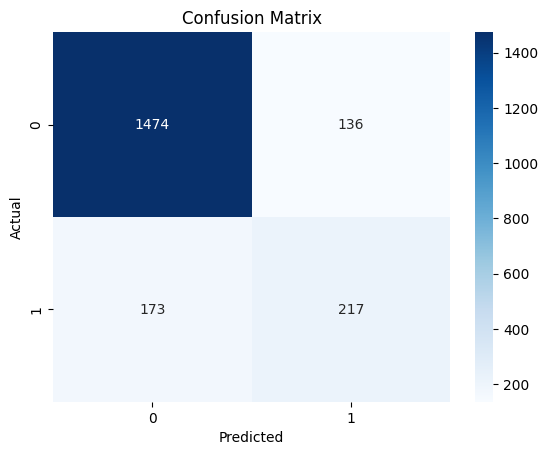

In [46]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()